In [ ]:
!unzip "customer tickets support.zip"

Archive:  customer tickets support.zip
  inflating: customer_support_tickets.csv  


In [ ]:
import os
print(os.listdir())

['.config', 'customer tickets support.zip', 'customer_support_tickets.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [46]:
import warnings
warnings.filterwarnings("ignore")

In [49]:
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = {
    "ticket": [
        "Internet is not working",
        "Unable to login to my account",
        "Payment failed during transaction",
        "Need to reset my password",
        "Network connection is very slow",
        "Money deducted but order not placed",
        "Application is crashing",
        "Cannot access my account",
        "Refund is not received",
        "Server is down"
    ],

    "category": [
        "Network",
        "Account",
        "Payment",
        "Account",
        "Network",
        "Payment",
        "Technical",
        "Account",
        "Payment",
        "Technical"
    ]
}

df = pd.DataFrame(data)

df

,ticket,category
0,Internet is not working,Network
1,Unable to login to my account,Account
2,Payment failed during transaction,Payment
3,Need to reset my password,Account
4,Network connection is very slow,Network
5,Money deducted but order not placed,Payment
6,Application is crashing,Technical
7,Cannot access my account,Account
8,Refund is not received,Payment
9,Server is down,Technical


In [ ]:
X = df["ticket"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("cell 4 is completed")

cell 4 is completed


In [ ]:
vectorizer = TfidfVectorizer()

X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train_vector, y_train)

print("Model Training Completed")

Model Training Completed


In [48]:
y_pred = model.predict(X_test_vector)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.5
              precision    recall  f1-score   support

     Account       1.00      1.00      1.00         1
     Network       0.00      0.00      0.00         0
     Payment       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.33      0.33      0.33         2
weighted avg       0.50      0.50      0.50         2



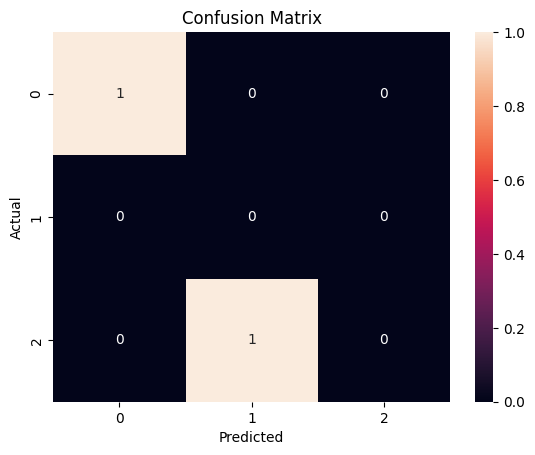

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
new_ticket = ["I cannot make payment using my card"]

new_ticket_vector = vectorizer.transform(new_ticket)

result = model.predict(new_ticket_vector)

print("Ticket Category:", result[0])

Ticket Category: Account


In [ ]:
import pickle

pickle.dump(model, open("ticket_classifier.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

print("Model Saved Successfully")

Model Saved Successfully


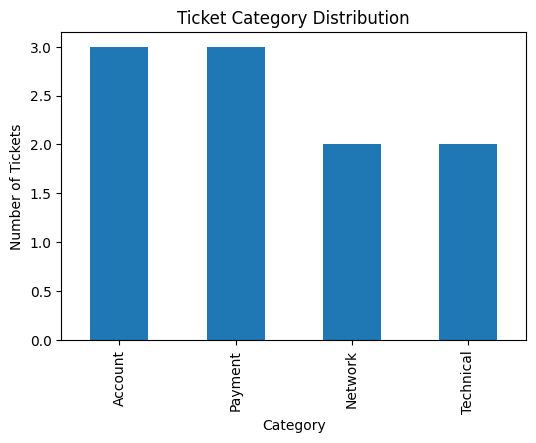

In [ ]:
plt.figure(figsize=(6,4))

df["category"].value_counts().plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.title("Ticket Category Distribution")

plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

for name, model_test in models.items():
    model_test.fit(X_train_vector, y_train)
    pred = model_test.predict(X_test_vector)

    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("----------------")

Logistic Regression
Accuracy: 0.5
----------------
Naive Bayes
Accuracy: 0.5
----------------
SVM
Accuracy: 0.5
----------------


In [ ]:
def predict_ticket(ticket):
    ticket_vector = vectorizer.transform([ticket])
    prediction = model.predict(ticket_vector)
    return prediction[0]

user_ticket = input("Enter your complaint: ")

print("Predicted Category:", predict_ticket(user_ticket))

Enter your complaint: my network is slow
Predicted Category: Network


In [ ]:
import pickle

with open("ticket_model.pkl","wb") as f:
    pickle.dump(model,f)

with open("ticket_vectorizer.pkl","wb") as f:
    pickle.dump(vectorizer,f)

print("Project files saved")

Project files saved


In [ ]:
readme_content = """
# AI-Based Ticket Classification

## Project Description
This project uses Machine Learning to automatically classify customer support tickets into different categories.

## Technologies Used
- Python
- Machine Learning
- Scikit-learn
- NLP (TF-IDF)
"""

print("README content created")

README content created
